# Кросс-энтропийный метод

Этот ноутбук научит Вас решать задачи обучения с подкреплением кросс-энтропийным методом. В дальнейшем мы отмасштабируем данный результат и будем использовать нейросетевую политику.

In [1]:
# !apt install ffmpeg xvfb python-opengl # для UNIX-подобных операционных систем
# !brew install XQuartz # для использования xvfb в MacOS сервере (не опробовано)
# !pip install piglet pyvirtualdisplay
# !pip install gymnasium

In [2]:
# from pyvirtualdisplay import Display # для визуализации на UNIX-подобном сервере


# virtual_display = Display(visible=0, size=(1920, 1080))
# virtual_display.start()

Скрыть предупреждения:

In [3]:
import warnings
from functools import partial
import matplotlib.pyplot as plt
%matplotlib inline


warnings.filterwarnings("ignore")

Подключение основных библиотек, в комментариях код для запуска ноутбука на `Unix`-сервере (необходим для отображения работы `RL`-среды)

In [4]:
# В Google Colab или на Unix-сервере (альтернатива pyvirtualdisplay), раскоментируйте код ниже:
# !wget https://bit.ly/2FMJP5K -O setup.py && bash setup.py # после этого переустановать gymnasium


# Данный код создаёт виртуальный экран для отрисовки фреймов игры.
# При локальном запуске можно проигнорировать
import os
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    !bash xvfb start
    os.environ['DISPLAY'] = ':1'

Поработаем со средой [Taxi-v3](https://gymnasium.farama.org/environments/toy_text/taxi/) в библиотеке [Gymnasium](https://github.com/Farama-Foundation/Gymnasium):

In [5]:
import gymnasium as gym
import numpy as np
import pandas as pd


TIME_LIMIT = 10000

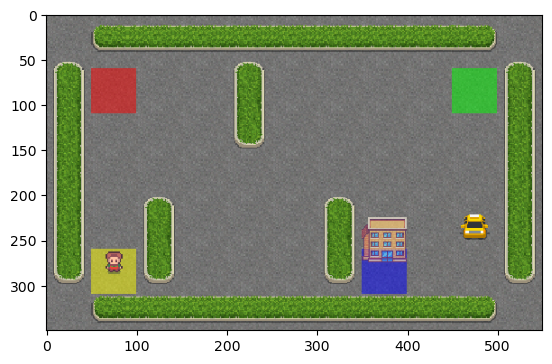

In [6]:
env = gym.make("Taxi-v3", render_mode="rgb_array").env
env.reset()
plt.imshow(env.render())
plt.show()

Увеличим максимальную длину эпизода в среде:

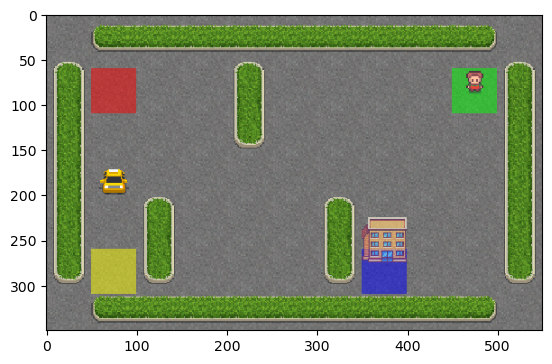

In [7]:
env = gym.wrappers.TimeLimit(
    gym.envs.toy_text.TaxiEnv(render_mode="rgb_array"),
    max_episode_steps=TIME_LIMIT + 1,
)
env.reset()
plt.imshow(env.render())
plt.show()

In [8]:
n_states = env.observation_space.n
n_actions = env.action_space.n

print("количество состояний = %i, количество действий = %i" % (n_states, n_actions))

количество состояний = 500, количество действий = 6


# Определим стохастическую политику

В этот раз наша политика будет задаваться вероятностным распределением.

```policy[s,a] = P(выполнить действие a | находясь в состоянии s)```

Поскольку мы по-прежнему используем целочисленные представления состояний и действий, для представления политики можно использовать двумерный массив.

Просьба инициализоровать политику __равномерно__, так что, вероятности всех действий должны быть одинаковыми.

In [9]:
policy = np.full((n_states, n_actions), 1. / n_actions)

In [10]:
assert type(policy) in (np.ndarray, np.matrix)
assert np.allclose(policy, 1./n_actions)
assert np.allclose(np.sum(policy, axis=1), 1)

# Сыграем в игру

Как раньше, но ещё запишем все состояния и совершённые действия.

In [11]:
def generate_session(policy, t_max=TIME_LIMIT, use_action_mask=False):
    """
    Взаимодействует со средой до терминального состояния или до t_max шагов.
    
    
    :параметр policy: NumPy-массив с размерностями [n_states, n_actions], заполненный вероятностями действий
    :возвращает: список состояний, список действий и сумма наград
    """
    states, actions = [], []
    total_reward = 0.

    s, info = env.reset()

    for t in range(t_max):

        # print(s)
        if use_action_mask and ("action_mask" in info):
            mask = info["action_mask"] > 0
            probs = policy[s, mask]
            probs /= max(np.sum(probs), 1e-16)
            a = np.random.choice(np.arange(n_actions)[mask], p=probs)
        else:
            a = np.random.choice(np.arange(n_actions), p=policy[s])

        new_s, r, terminated, truncated, info = env.step(a)

        # Запись состояния, действия и суммирование награды в states, actions и total_reward соответственно.
        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if terminated or truncated:
            break
    return states, actions, total_reward

In [12]:
from IPython import display
import time


def visualize_session(policy, t_max=TIME_LIMIT, use_action_mask=False):
    """
    Взаимодействует со средой до терминального состояния или до t_max шагов.
    
    
    :параметр policy: NumPy-массив с размерностями [n_states, n_actions], заполненный вероятностями действий
    :возвращает: сумма наград
    """
    total_reward = 0.

    s, info = env.reset()

    plt.figure(figsize=(6, 4))
    display.clear_output(wait=True)

    for t in range(t_max):
        plt.gca().clear()
        # отрисовка фрейма игры на дисплее
        plt.imshow(env.render())
        display.clear_output(wait=True)
        display.display(plt.gcf())
        time.sleep(0.25)

        # print(s)
        if use_action_mask and ("action_mask" in info):
            mask = info["action_mask"] > 0
            probs = policy[s, mask]
            probs /= max(np.sum(probs), 1e-16)
            a = np.random.choice(np.arange(n_actions)[mask], p=probs)
        else:
            a = np.random.choice(np.arange(n_actions), p=policy[s])

        new_s, r, terminated, truncated, info = env.step(a)

        # Суммирование награды в total_reward.
        total_reward += r

        s = new_s
        if terminated:
            plt.gca().clear()
            display.clear_output(wait=True)
            print("Достигли терминального состояния:")
            break
        if truncated:
            plt.gca().clear()
            display.clear_output(wait=True)
            print("Взаимодействие со средой прервано:")
            break

    plt.imshow(env.render())
    plt.show()
    print(f"Суммарная награда за сессию: {total_reward:.4f}")
    return total_reward

In [13]:
s, a, r = generate_session(policy)
assert type(s) == type(a) == list
assert len(s) == len(a)
assert type(r) in [float, np.float64]

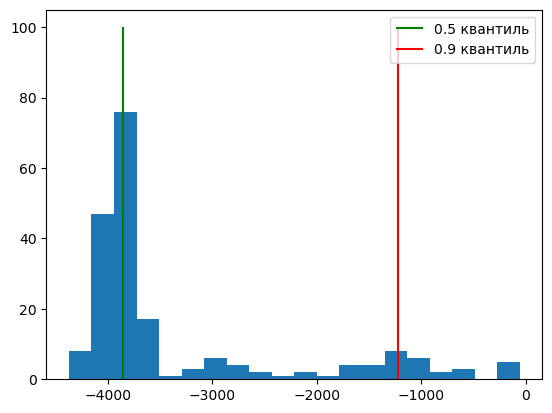

In [14]:
# давайте взглянем на изначальное распределеине награды

sample_rewards = [generate_session(policy, t_max=1000)[-1] for _ in range(200)]

plt.hist(sample_rewards, bins=20)
plt.vlines([np.percentile(sample_rewards, 50)], [0], [100], label="0.5 квантиль", color='green')
plt.vlines([np.percentile(sample_rewards, 90)], [0], [100], label="0.9 квантиль", color='red')
plt.legend()
plt.show()

In [15]:
len(s)

7822

### Шаги кросс-энтропийного метода

In [16]:
def select_elites(states_batch, actions_batch, rewards_batch, percentile=50):
    """
    Выбор состояний и действий из эпизодов с суммарной наградой >= percentile
    :параметр states_batch: список списков состояний, states_batch[session_i][t]
    :параметр actions_batch: список списков действий, actions_batch[session_i][t]
    :параметр rewards_batch: список суммарных наград, rewards_batch[session_i]

    :возвращает: elite_states, elite_actions, 1D списки состояний и соответствующих действий из отобранных эпизодов

    Просьба врзвращать отобранные состояния и действия в исходном порядке 
    [т.е. сортированные по номеру эпизода и в хронологическом порядке внутри эпизода]

    В случае замешательства просьба обратить внимание на примеры ниже. Просьба не трактовать состояния как целые
    числа (они могут позже стать другими).
    """
    
    reward_threshold = np.percentile(rewards_batch, q=percentile)
    mask = np.array(rewards_batch) >= reward_threshold

    #print("mask", mask)
    #print("states", states_batch)
    elite_states = np.hstack([np.array(s) for s, m in zip(states_batch, mask) if m])
    #print("actions", actions_batch)
    elite_actions = np.hstack([np.array(a) for a, m in zip(actions_batch, mask) if m])

    return elite_states, elite_actions

In [17]:
states_batch = [
    [1, 2, 3],     # эпизод 1
    [4, 2, 0, 2],  # эпизод 2
    [3, 1],        # эпизод 3
]

actions_batch = [
    [0, 2, 4],     # эпизод 1
    [3, 2, 0, 1],  # эпизод 2
    [3, 3],        # эпизод 3
]
rewards_batch = [
    3,  # эпизод 1
    4,  # эпизод 2
    5,  # эпизод 3
]

test_result_0 = select_elites(
    states_batch, actions_batch, rewards_batch, percentile=0)
test_result_30 = select_elites(
    states_batch, actions_batch, rewards_batch, percentile=30)
test_result_90 = select_elites(
    states_batch, actions_batch, rewards_batch, percentile=90)
test_result_100 = select_elites(
    states_batch, actions_batch, rewards_batch, percentile=100)

assert np.all(test_result_0[0] == [1, 2, 3, 4, 2, 0, 2, 3, 1])  \
    and np.all(test_result_0[1] == [0, 2, 4, 3, 2, 0, 1, 3, 3]),\
    "Для квантиля 0 следует вернуть все состояния и действия в хронологическом порядке"
assert np.all(test_result_30[0] == [4, 2, 0, 2, 3, 1]) and \
    np.all(test_result_30[1] == [3, 2, 0, 1, 3, 3]),\
    "Для квантиля 0.3 следует вернуть состояния/действия из последних двух эпизодов"
assert np.all(test_result_90[0] == [3, 1]) and \
    np.all(test_result_90[1] == [3, 3]),\
    "Для квантиля 0.9 следует вернуть состояния/действия только из третьего эпизода"
assert np.all(test_result_100[0] == [3, 1]) and\
    np.all(test_result_100[1] == [3, 3]),\
    "Используйте >=, не >. Дважды проверьте вычисление перцентилей (квантилей)."
print("Отлично!")

Отлично!


In [18]:
def update_policy(elite_states, elite_actions):
    """
    По данной старой политике и по списку отобранных состояний/действий из select_elites вернуть новую политику
    с вероятностью совершения действия пропорционально:
    
    policy[s_i,a_i] ~ #[пары s_i и a_i в отобранных состояниях/действиях].
    
    Не забывайте нормализовать политику, чтобы получить корректное вероятностное распределение и
    учесть случай 0/0. Для непосещённых состояний установить равномерное распределение на действия:
    
    policy[s_i,a_i] = 1./n_actions.

    :параметр elite_states: 1D список состояний из отобранных эпизодов
    :параметр elite_actions: 1D список действий из отобранных эпизодов

    """

    new_policy = np.zeros([n_states, n_actions])

    #for s, a in zip(elite_states, elite_actions):
    #    new_policy[s, a] += 1
    np.add.at(new_policy, (elite_states, elite_actions), 1)
    mask = new_policy.sum(axis=1) > 0
    new_policy[mask] /= new_policy[mask].sum(axis=1)[:, np.newaxis]
    # Не забудьте выставить 1/n_actions для непосещённых состояний.
    new_policy[~mask] = 1 / n_actions

    return new_policy

In [19]:
elite_states = [1, 2, 3, 4, 2, 0, 2, 3, 1]
elite_actions = [0, 2, 4, 3, 2, 0, 1, 3, 3]

new_policy = update_policy(elite_states, elite_actions)

assert np.isfinite(new_policy).all(
), "Ваша новая политика содержит NaN-ы или +-inf. Проверьте наличие деления на 0."
assert np.all(
    new_policy >= 0), "Ваша новая политика не может содержать отрицательные вероятности"
assert np.allclose(new_policy.sum(
    axis=-1), 1), "Ваша новая политика должна быть корректным вероятностным распределением на действиях"
reference_answer = np.array([
    [1.,  0.,  0.,  0.,  0.],
    [.5,  0.,  0.,  .5,  0.],
    [0.,  .33333333,  .66666667,  0.,  0.],
    [0.,  0.,  0.,  .5,  .5]])
assert np.allclose(new_policy[:4, :5], reference_answer)
print("Отлично!")

Отлично!


# Цикл обучения

Сгенерируйте эпизоды, выберете N лучших и обучитесь на них.

In [20]:
from IPython.display import clear_output


def show_progress(rewards_batch, log, percentile, reward_range=[-990, +10]):
    """
    Удобная функция для демонстрации процесса обучения. Никакого rocket science, просто диаграммы.
    """

    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    log.append([mean_reward, threshold])

    print("Среднее арифметическое суммарной награды = %.3f, порог=%.3f" % (mean_reward, threshold))
    plt.figure(figsize=[8, 4])
    plt.subplot(1, 2, 1)
    plt.plot(list(zip(*log))[0], label='Среднее арифметическое\nсуммарной награды')
    plt.plot(list(zip(*log))[1], label='Пороги суммарных наград')
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.hist(rewards_batch, range=reward_range)
    plt.vlines([np.percentile(rewards_batch, percentile)],
               [0], [100], label="перцентиль", color='red')
    plt.legend()
    plt.grid()
    
    clear_output(True)
    plt.show()

In [21]:
# перезапись политики на всякий случай
policy = np.ones([n_states, n_actions]) / n_actions

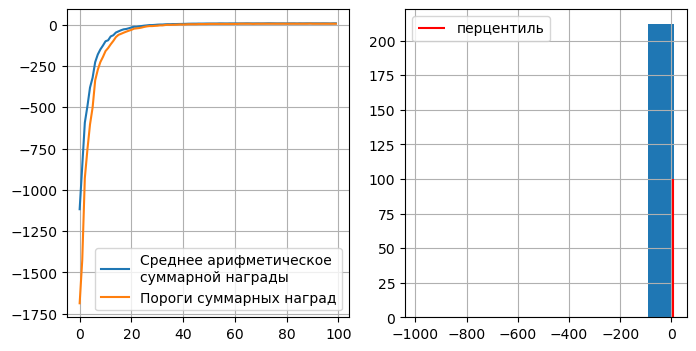

In [22]:
n_sessions = 250  # сэмплировать столько эпизодов
percentile = 20  # исключить такой процент худших наград
learning_rate = .5  # коэффициент экспоненциального сглаживания для вероятностей

log = []

for i in range(100):

    %time sessions = [generate_session(policy, t_max=TIME_LIMIT, use_action_mask=True) for _ in range(n_sessions)]

    #states_batch, actions_batch, rewards_batch = zip(*sessions)
    states_batch, actions_batch, rewards_batch = map(partial(np.array, dtype=object), zip(*sessions))

    elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile=percentile)

    new_policy = update_policy(elite_states, elite_actions)

    policy = learning_rate * new_policy + (1. - learning_rate) * policy
    learning_rate *= 0.99

    # отображение результатов на диаграмме
    show_progress(rewards_batch, log, percentile)

Демонстрация обученной стратегии:

Достигли терминального состояния:


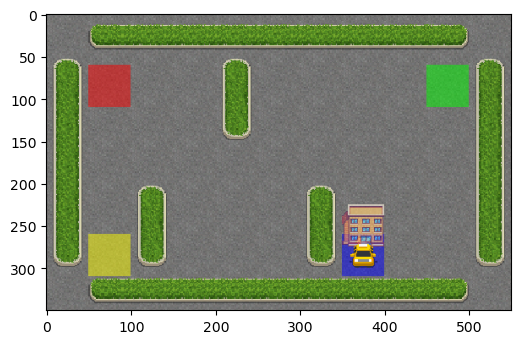

Суммарная награда за сессию: 8.0000


In [23]:
_ = visualize_session(policy, t_max=TIME_LIMIT, use_action_mask=True)

Средняя награда после обучения:

In [24]:
print(np.mean(rewards_batch))

7.384


Порог по награде для отбора траекторий после обучения:

In [25]:
threshold = np.percentile(rewards_batch, percentile)
print(threshold)

5.0


Визуализация стратегии после обучения:

In [26]:
policy.shape

(500, 6)

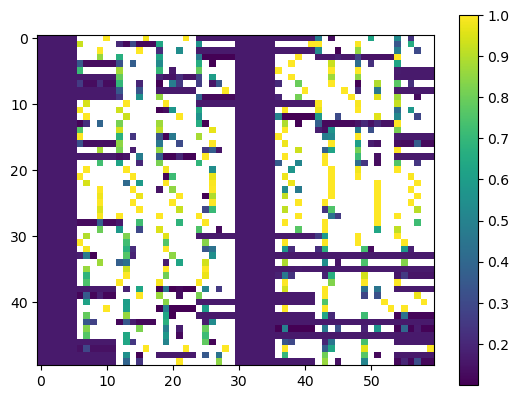

In [27]:
reshaped_policy = policy.reshape(50, 60)
im = plt.imshow(np.ma.masked_where(reshaped_policy < 1e-1, reshaped_policy))
plt.colorbar(im)
plt.show()

# Такси, но уже в дождливую погоду

Теперь автомобиль имеет вероятность 0.1 повернуть влево относительно текущего направления движения и вероятность 0.1 повернуть направо

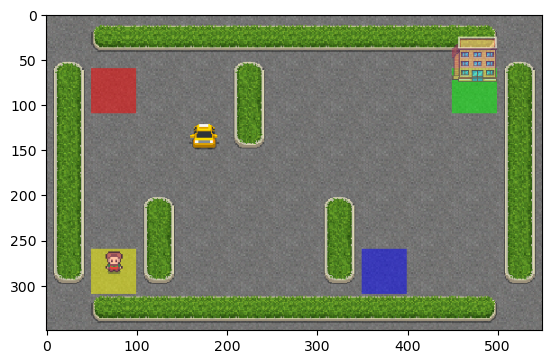

In [28]:
env = gym.wrappers.TimeLimit(
    gym.envs.toy_text.TaxiEnv(render_mode="rgb_array", is_rainy=True),
    max_episode_steps=TIME_LIMIT + 1,
)
env.reset()
plt.imshow(env.render())
plt.show()

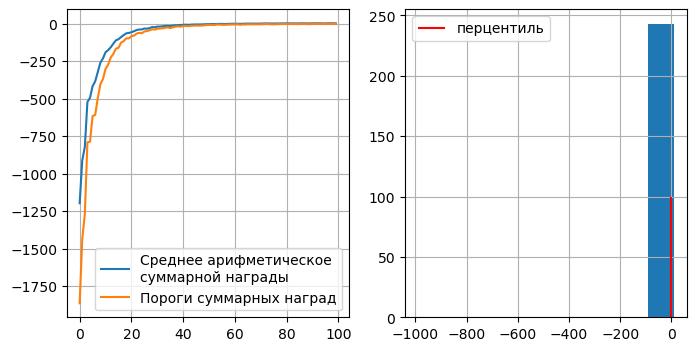

In [29]:
policy = np.ones([n_states, n_actions]) / n_actions

n_sessions = 250  # сэмплировать столько эпизодов
percentile = 20  # исключить такой процент худших наград
learning_rate = .5  # коэффициент экспоненциального сглаживания для вероятностей

log = []

for i in range(100):

    %time sessions = [generate_session(policy, t_max=TIME_LIMIT, use_action_mask=True) for _ in range(n_sessions)]

    #states_batch, actions_batch, rewards_batch = zip(*sessions)
    states_batch, actions_batch, rewards_batch = map(partial(np.array, dtype=object), zip(*sessions))

    elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile=percentile)

    new_policy = update_policy(elite_states, elite_actions)

    policy = learning_rate * new_policy + (1. - learning_rate) * policy
    learning_rate *= 0.99

    # отображение результатов на диаграмме
    show_progress(rewards_batch, log, percentile)

Демонстрация обученной стратегии:

Достигли терминального состояния:


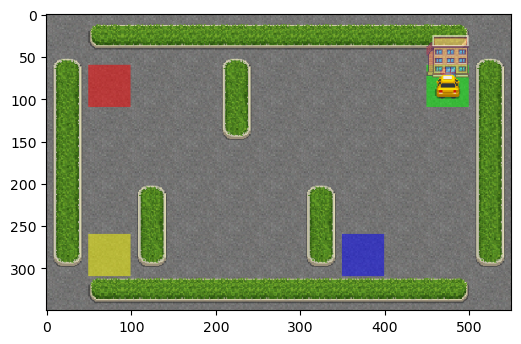

Суммарная награда за сессию: 5.0000


In [30]:
_ = visualize_session(policy, t_max=TIME_LIMIT, use_action_mask=True)

Средняя награда после обучения:

In [31]:
print(np.mean(rewards_batch))

2.404


Порог по награде для отбора траекторий после обучения:

In [32]:
threshold = np.percentile(rewards_batch, percentile)
print(threshold)

-1.0


Визуализация стратегии после обучения:

In [33]:
policy.shape

(500, 6)

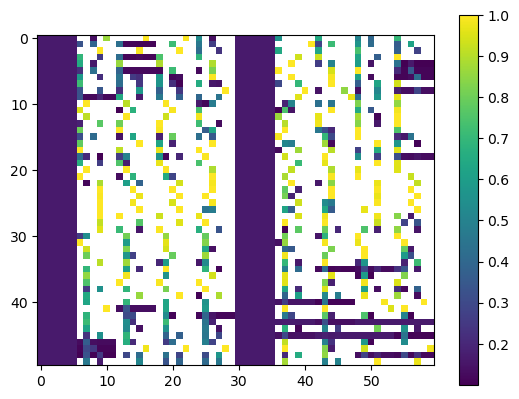

In [34]:
reshaped_policy = policy.reshape(50, 60)
im = plt.imshow(np.ma.masked_where(reshaped_policy < 1e-1, reshaped_policy))
plt.colorbar(im)
plt.show()

# Такси, но к дождю добавляется забывчивость пассажира 

Теперь пассажир с вероятностью 0.3 меняет точку назначения через 1 шаг автомобиля с точки подбора пассажира

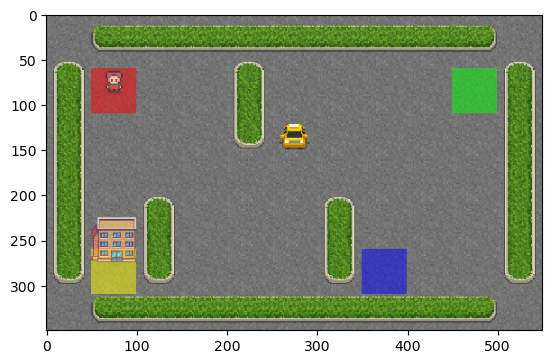

In [35]:
env = gym.wrappers.TimeLimit(
    gym.envs.toy_text.TaxiEnv(render_mode="rgb_array", is_rainy=True, fickle_passenger=True),
    max_episode_steps=TIME_LIMIT + 1,
)
env.reset()
plt.imshow(env.render())
plt.show()

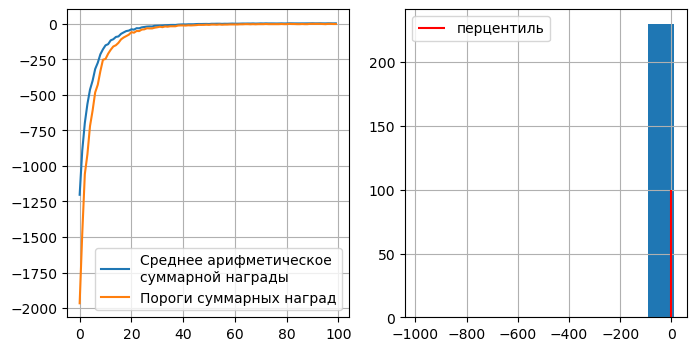

In [36]:
policy = np.ones([n_states, n_actions]) / n_actions

n_sessions = 250  # сэмплировать столько эпизодов
percentile = 20  # исключить такой процент худших наград
learning_rate = .5  # коэффициент экспоненциального сглаживания для вероятностей

log = []

for i in range(100):

    %time sessions = [generate_session(policy, t_max=TIME_LIMIT, use_action_mask=True) for _ in range(n_sessions)]

    #states_batch, actions_batch, rewards_batch = zip(*sessions)
    states_batch, actions_batch, rewards_batch = map(partial(np.array, dtype=object), zip(*sessions))

    elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile=percentile)

    new_policy = update_policy(elite_states, elite_actions)

    policy = learning_rate * new_policy + (1. - learning_rate) * policy
    learning_rate *= 0.99

    # отображение результатов на диаграмме
    show_progress(rewards_batch, log, percentile)

Демонстрация обученной стратегии:

Достигли терминального состояния:


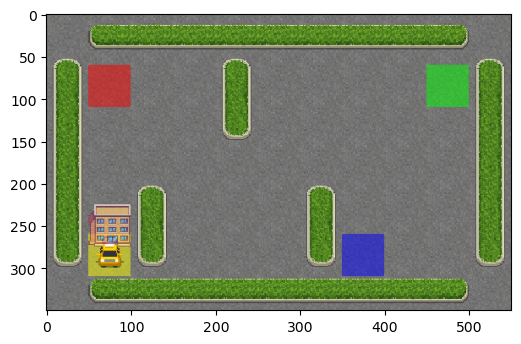

Суммарная награда за сессию: 15.0000


In [37]:
_ = visualize_session(policy, t_max=TIME_LIMIT, use_action_mask=True)

Средняя награда после обучения:

In [38]:
print(np.mean(rewards_batch))

3.712


Порог по награде для отбора траекторий после обучения:

In [39]:
threshold = np.percentile(rewards_batch, percentile)
print(threshold)

-1.0


Визуализация стратегии после обучения:

In [40]:
policy.shape

(500, 6)

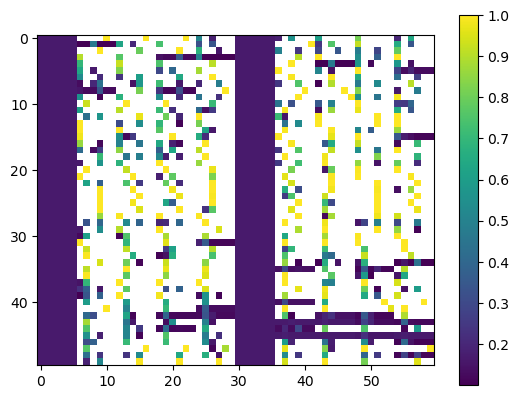

In [41]:
reshaped_policy = policy.reshape(50, 60)
im = plt.imshow(np.ma.masked_where(reshaped_policy < 1e-1, reshaped_policy))
plt.colorbar(im)
plt.show()

### Обсуждение результатов

Возможно, вы заметили, что задача о такси быстро сходится от $\leq-1000$ к почти оптимальному значению, а затем снова опускается до -50/-100 (иногда). Частично это связано с тем, что окружающая среда обладает некоторой врожденной случайностью. А именно, отправные точки пассажира/водителя меняются от эпизода к эпизоду.

Если кросс-энтропийный метод не сможет научиться побеждать с одной конкретной отправной точки, он просто откажется от нее, потому что ни одна сессия с этой отправной точки не попадет в «отобранные».

Чтобы смягчить эту проблему, вы можете либо снизить порог отобранных сессий (метод проб и ошибок), либо изменить способ оценки стратегии (теоретически правильный способ). Вы можете сначала попробовать действие для каждого возможного состояния, а затем оценить этот выбор действий, запустив _несколько_ игр и усреднив награды.